### Charge 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
csv_file = Path("PEM_ina226_log_20260422_150324.csv")

# Negative current = discharge
discharge_threshold_mA = -10.0

# Battery nominal energy
battery_capacity_Wh = 7.4

# Weighting for combined SoC estimate
# 0.7 = energy-based, 0.3 = voltage-based
soc_energy_weight = 0.7
soc_voltage_weight = 0.3

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

# ----------------------------
# Find discharge block
# ----------------------------
is_discharge = df["current_mA"] < discharge_threshold_mA

if not is_discharge.any():
    raise ValueError(
        f"No rows found with current_mA < {discharge_threshold_mA}. "
        f"Try threshold -1.0 or -0.1"
    )

start_idx = is_discharge.idxmax()
df_after_start = df.loc[start_idx:].copy()
is_discharge_after = df_after_start["current_mA"] < discharge_threshold_mA

stop_candidates = df_after_start.index[~is_discharge_after]

if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_plot = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_plot = df.loc[start_idx:].copy()

if df_plot.empty:
    raise ValueError("Filtered dataframe is empty after discharge block detection.")

# ----------------------------
# Time handling
# ----------------------------
df_plot["t_hours"] = (
    df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
).dt.total_seconds() / 3600.0

dt_s = df_plot["pc_time"].diff().dt.total_seconds()
dt_s.iloc[0] = 0
dt_s = dt_s.clip(lower=0, upper=10)
df_plot["dt_s"] = dt_s

# ----------------------------
# Power / energy as absolute discharge values
# ----------------------------
df_plot["discharge_power_W"] = df_plot["power_mW"].abs() / 1000.0
df_plot["dE_Wh"] = df_plot["discharge_power_W"] * df_plot["dt_s"] / 3600.0
df_plot["cum_energy_Wh"] = df_plot["dE_Wh"].cumsum()

# ----------------------------
# Minute averaging
# ----------------------------
df_min = df_plot.set_index("pc_time").resample("1min").mean(numeric_only=True)
df_min = df_min.dropna(subset=["power_mW", "bus_V"]).copy()

df_min["discharge_power_W"] = df_min["power_mW"].abs() / 1000.0
df_min["dE_Wh"] = df_min["discharge_power_W"] * (1 / 60.0)
df_min["cum_energy_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# ----------------------------
# SoC estimate
# ----------------------------

# 1) Energy-based SoC
df_min["soc_energy_percent"] = 100 * (1 - df_min["cum_energy_Wh"] / battery_capacity_Wh)
df_min["soc_energy_percent"] = df_min["soc_energy_percent"].clip(lower=0, upper=100)

# 2) Voltage-based SoC
# Simple normalization across discharge range:
# start voltage -> 100%, end voltage -> 0%
V_max = df_min["bus_V"].iloc[0]
V_min = df_min["bus_V"].min()

if abs(V_max - V_min) < 1e-9:
    df_min["soc_voltage_percent"] = 100.0
else:
    df_min["soc_voltage_percent"] = 100 * (df_min["bus_V"] - V_min) / (V_max - V_min)
    df_min["soc_voltage_percent"] = df_min["soc_voltage_percent"].clip(lower=0, upper=100)

# 3) Combined SoC estimate using both energy and voltage
df_min["soc_estimated_percent"] = (
    soc_energy_weight * df_min["soc_energy_percent"] +
    soc_voltage_weight * df_min["soc_voltage_percent"]
).clip(lower=0, upper=100)

# ----------------------------
# Plot 1: Voltage + Current
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_plot["t_hours"],
    df_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("Time [hours]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_hours"],
    df_plot["current_mA"],
    color="tab:red",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Battery Discharge: Bus Voltage and Current (using 22ohm resistive load)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()

# ----------------------------
# Plot 2: Absolute discharge power
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["power_mW"].abs(),
    color="tab:green",
    alpha=0.35,
    label=" Discharge Power |mW|"
)
plt.plot(
    df_min["t_hours"],
    df_min["power_mW"].abs(),
    color="tab:orange",
    linewidth=2,
    label="1-min Avg Discharge Power |mW|"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharge Power [mW]")
plt.title("Battery Discharge Power (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 3: Absolute cumulative discharged energy
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["cum_energy_Wh"].abs(),
    color="tab:purple",
    alpha=0.4,
    label=" integrated energy [Wh]"
)
plt.plot(
    df_min["t_hours"],
    df_min["cum_energy_Wh"].abs(),
    color="tab:brown",
    linewidth=2,
    label="1-min Avg integrated energy [Wh]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharged Energy [Wh]")
plt.title("Cumulative Discharged Energy (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 4: SoC estimate
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_min["t_hours"],
    df_min["soc_energy_percent"],
    color="tab:gray",
    linestyle="--",
    linewidth=2,
    label="SoC from Energy [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_voltage_percent"],
    color="tab:olive",
    linestyle=":",
    linewidth=2,
    label="SoC from Voltage [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_estimated_percent"],
    color="tab:cyan",
    linewidth=2.5,
    label="Estimated SoC [%]"
)
plt.xlabel("Time [hours]")
plt.ylabel("SoC [%]")
plt.title("Estimated State of Charge")
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

# ----------------------------
# Plot 5: Voltage, Current, Power vs SoC
# ----------------------------
import numpy as np

soc_plot = df_min.dropna(subset=["bus_V", "current_mA", "power_mW", "cum_energy_Wh"]).copy()

# Define plot SoC so the measured discharge runs from 100% to 0%
soc_plot["soc_plot_percent"] = 100 * (
    1 - soc_plot["cum_energy_Wh"] / soc_plot["cum_energy_Wh"].iloc[-1]
)
soc_plot["soc_plot_percent"] = soc_plot["soc_plot_percent"].clip(0, 110)

# Sort by SoC descending for clean plotting
soc_plot = soc_plot.sort_values("soc_plot_percent", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))

# Voltage on left axis
ax1.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("State of Charge [%]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Current on first right axis (negative = discharge)
ax2 = ax1.twinx()
ax2.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["current_mA"],
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(min(soc_plot["current_mA"]) * 1.05, 0)

# Power on second right axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["power_mW"].abs(),
    color="tab:green",
    linewidth=2,
    label="Power [mW]"
)
ax3.set_ylabel("Power [mW]", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Force SoC axis from 100 to 0 with 10% intervals
ax1.set_xlim(105, -5)
ax1.set_xticks(np.arange(100, -1, -10))

ax1.set_title("Battery Voltage, Current, and Power vs State of Charge (using 22ohm resistive load)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best"
)

plt.tight_layout()
plt.show()
# ----------------------------
# Summary
# ----------------------------
print(f"Original rows: {len(df)}")
print(f"Discharge rows used: {len(df_plot)}")
print(f"Discharge start: {df_plot['pc_time'].iloc[0]}")
print(f"Discharge end:   {df_plot['pc_time'].iloc[-1]}")
print(f"Duration:        {df_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Final integrated energy: {df_plot['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final 1-min averaged integrated energy: {df_min['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from energy: {df_min['soc_energy_percent'].iloc[-1]:.2f} %")
print(f"Final SoC from voltage: {df_min['soc_voltage_percent'].iloc[-1]:.2f} %")
print(f"Final estimated SoC: {df_min['soc_estimated_percent'].iloc[-1]:.2f} %")

### Discharge 1

C:\Users\Jacob\AppData\Local\Temp\ipykernel_4092\112435513.py:71: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0


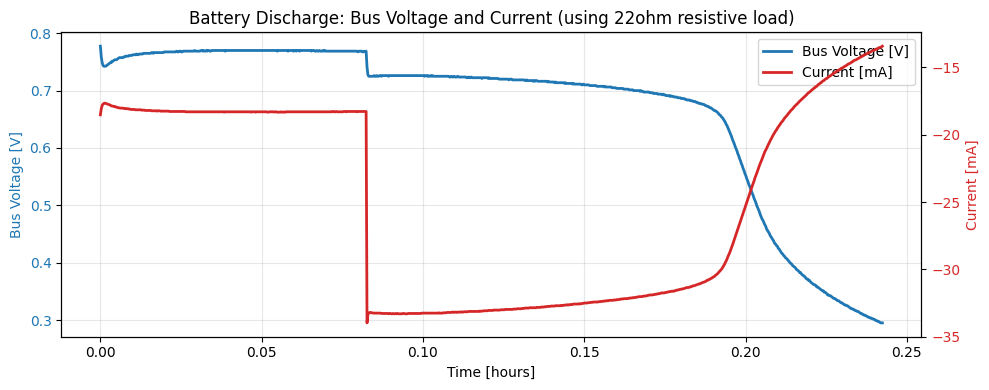

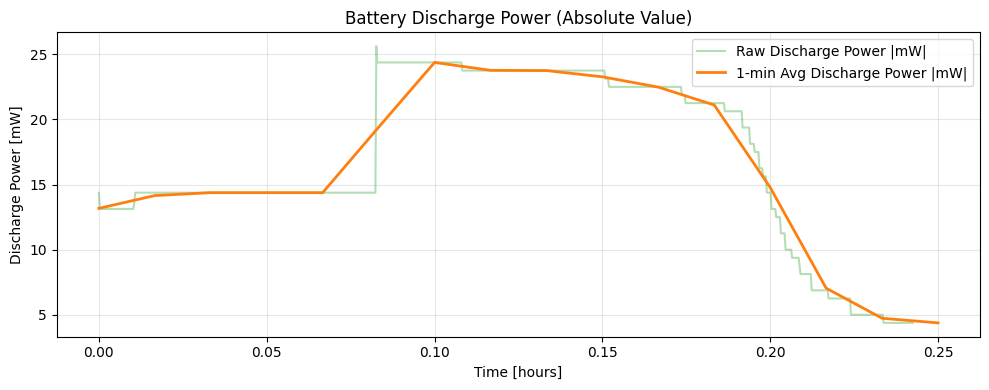

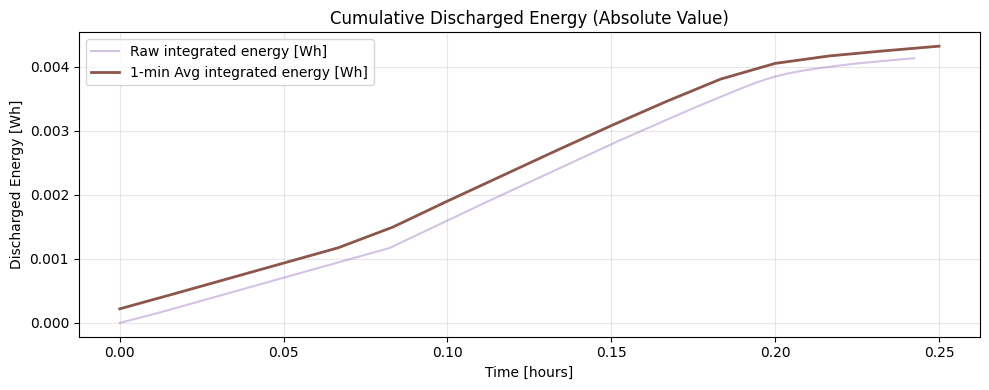

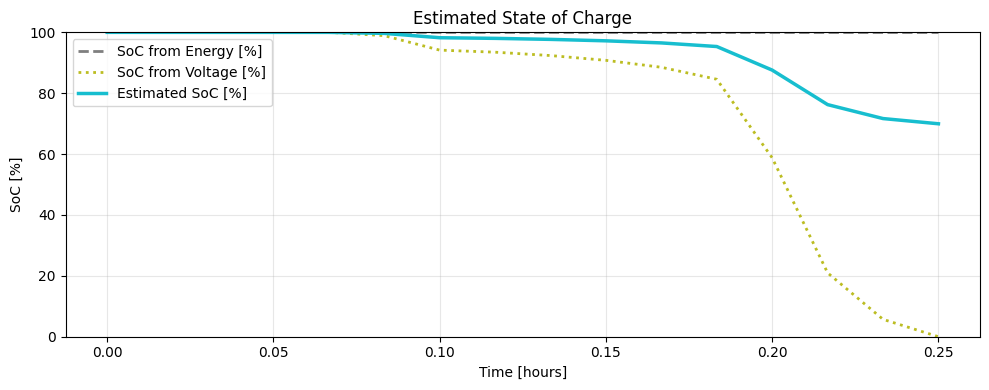

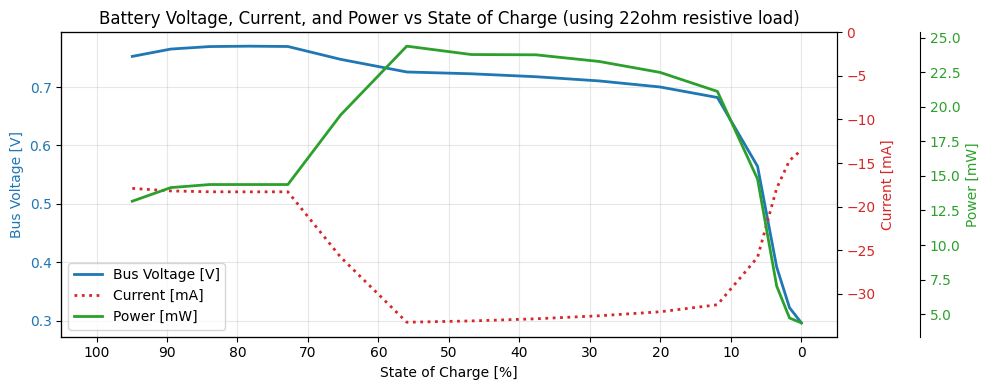

Original rows: 880
Discharge rows used: 872
Discharge start: 2026-04-22 15:03:32.838000
Discharge end:   2026-04-22 15:18:05.568000
Duration:        0.242 h
Final integrated energy: 0.0041 Wh
Final 1-min averaged integrated energy: 0.0043 Wh
Final SoC from energy: 99.94 %
Final SoC from voltage: 0.00 %
Final estimated SoC: 69.96 %


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
csv_file = Path("PEM_ina226_log_20260422_150324.csv")

# Negative current = discharge
discharge_threshold_mA = -10.0

# Battery nominal energy
battery_capacity_Wh = 7.4

# Weighting for combined SoC estimate
# 0.7 = energy-based, 0.3 = voltage-based
soc_energy_weight = 0.7
soc_voltage_weight = 0.3

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(csv_file)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
df = df.dropna(subset=["pc_time"]).copy()
df = df.sort_values("pc_time").reset_index(drop=True)
df = df.drop_duplicates(subset="pc_time", keep="first").copy()

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()

# ----------------------------
# Find discharge block
# ----------------------------
is_discharge = df["current_mA"] < discharge_threshold_mA

if not is_discharge.any():
    raise ValueError(
        f"No rows found with current_mA < {discharge_threshold_mA}. "
        f"Try threshold -1.0 or -0.1"
    )

start_idx = is_discharge.idxmax()
df_after_start = df.loc[start_idx:].copy()
is_discharge_after = df_after_start["current_mA"] < discharge_threshold_mA

stop_candidates = df_after_start.index[~is_discharge_after]

if len(stop_candidates) > 0:
    stop_idx = stop_candidates[0]
    df_plot = df.loc[start_idx:stop_idx - 1].copy()
else:
    df_plot = df.loc[start_idx:].copy()

if df_plot.empty:
    raise ValueError("Filtered dataframe is empty after discharge block detection.")

# ----------------------------
# Time handling
# ----------------------------
df_plot["t_hours"] = (
    df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
).dt.total_seconds() / 3600.0

dt_s = df_plot["pc_time"].diff().dt.total_seconds()
dt_s.iloc[0] = 0
dt_s = dt_s.clip(lower=0, upper=10)
df_plot["dt_s"] = dt_s

# ----------------------------
# Power / energy as absolute discharge values
# ----------------------------
df_plot["discharge_power_W"] = df_plot["power_mW"].abs() / 1000.0
df_plot["dE_Wh"] = df_plot["discharge_power_W"] * df_plot["dt_s"] / 3600.0
df_plot["cum_energy_Wh"] = df_plot["dE_Wh"].cumsum()

# ----------------------------
# Minute averaging
# ----------------------------
df_min = df_plot.set_index("pc_time").resample("1min").mean(numeric_only=True)
df_min = df_min.dropna(subset=["power_mW", "bus_V"]).copy()

df_min["discharge_power_W"] = df_min["power_mW"].abs() / 1000.0
df_min["dE_Wh"] = df_min["discharge_power_W"] * (1 / 60.0)
df_min["cum_energy_Wh"] = df_min["dE_Wh"].cumsum()
df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

# ----------------------------
# SoC estimate
# ----------------------------

# 1) Energy-based SoC
df_min["soc_energy_percent"] = 100 * (1 - df_min["cum_energy_Wh"] / battery_capacity_Wh)
df_min["soc_energy_percent"] = df_min["soc_energy_percent"].clip(lower=0, upper=100)

# 2) Voltage-based SoC
# Simple normalization across discharge range:
# start voltage -> 100%, end voltage -> 0%
V_max = df_min["bus_V"].iloc[0]
V_min = df_min["bus_V"].min()

if abs(V_max - V_min) < 1e-9:
    df_min["soc_voltage_percent"] = 100.0
else:
    df_min["soc_voltage_percent"] = 100 * (df_min["bus_V"] - V_min) / (V_max - V_min)
    df_min["soc_voltage_percent"] = df_min["soc_voltage_percent"].clip(lower=0, upper=100)

# 3) Combined SoC estimate using both energy and voltage
df_min["soc_estimated_percent"] = (
    soc_energy_weight * df_min["soc_energy_percent"] +
    soc_voltage_weight * df_min["soc_voltage_percent"]
).clip(lower=0, upper=100)

# ----------------------------
# Plot 1: Voltage + Current
# ----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_plot["t_hours"],
    df_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("Time [hours]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["t_hours"],
    df_plot["current_mA"],
    color="tab:red",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Battery Discharge: Bus Voltage and Current (using 22ohm resistive load)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()

# ----------------------------
# Plot 2: Absolute discharge power
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["power_mW"].abs(),
    color="tab:green",
    alpha=0.35,
    label="Discharge Power |mW|"
)
plt.plot(
    df_min["t_hours"],
    df_min["power_mW"].abs(),
    color="tab:orange",
    linewidth=2,
    label="1-min Avg Discharge Power |mW|"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharge Power [mW]")
plt.title("Battery Discharge Power (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 3: Absolute cumulative discharged energy
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_plot["t_hours"],
    df_plot["cum_energy_Wh"].abs(),
    color="tab:purple",
    alpha=0.4,
    label=" integrated energy [Wh]"
)
plt.plot(
    df_min["t_hours"],
    df_min["cum_energy_Wh"].abs(),
    color="tab:brown",
    linewidth=2,
    label="1-min Avg integrated energy [Wh]"
)
plt.xlabel("Time [hours]")
plt.ylabel("Discharged Energy [Wh]")
plt.title("Cumulative Discharged Energy (Absolute Value)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

# ----------------------------
# Plot 4: SoC estimate
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(
    df_min["t_hours"],
    df_min["soc_energy_percent"],
    color="tab:gray",
    linestyle="--",
    linewidth=2,
    label="SoC from Energy [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_voltage_percent"],
    color="tab:olive",
    linestyle=":",
    linewidth=2,
    label="SoC from Voltage [%]"
)
plt.plot(
    df_min["t_hours"],
    df_min["soc_estimated_percent"],
    color="tab:cyan",
    linewidth=2.5,
    label="Estimated SoC [%]"
)
plt.xlabel("Time [hours]")
plt.ylabel("SoC [%]")
plt.title("Estimated State of Charge")
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()

plt.show()

# ----------------------------
# Plot 5: Voltage, Current, Power vs SoC
# ----------------------------
import numpy as np

soc_plot = df_min.dropna(subset=["bus_V", "current_mA", "power_mW", "cum_energy_Wh"]).copy()

# Define plot SoC so the measured discharge runs from 100% to 0%
soc_plot["soc_plot_percent"] = 100 * (
    1 - soc_plot["cum_energy_Wh"] / soc_plot["cum_energy_Wh"].iloc[-1]
)
soc_plot["soc_plot_percent"] = soc_plot["soc_plot_percent"].clip(0, 110)

# Sort by SoC descending for clean plotting
soc_plot = soc_plot.sort_values("soc_plot_percent", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))

# Voltage on left axis
ax1.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["bus_V"],
    color="tab:blue",
    linewidth=2,
    label="Bus Voltage [V]"
)
ax1.set_xlabel("State of Charge [%]")
ax1.set_ylabel("Bus Voltage [V]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Current on first right axis (negative = discharge)
ax2 = ax1.twinx()
ax2.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["current_mA"],
    color="tab:red",
    linestyle=":",
    linewidth=2,
    label="Current [mA]"
)
ax2.set_ylabel("Current [mA]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(min(soc_plot["current_mA"]) * 1.05, 0)

# Power on second right axis
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(
    soc_plot["soc_plot_percent"],
    soc_plot["power_mW"].abs(),
    color="tab:green",
    linewidth=2,
    label="Power [mW]"
)
ax3.set_ylabel("Power [mW]", color="tab:green")
ax3.tick_params(axis="y", labelcolor="tab:green")

# Force SoC axis from 100 to 0 with 10% intervals
ax1.set_xlim(105, -5)
ax1.set_xticks(np.arange(100, -1, -10))

ax1.set_title("Battery Voltage, Current, and Power vs State of Charge (using 22ohm resistive load)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best"
)

plt.tight_layout()
plt.show()
# ----------------------------
# Summary
# ----------------------------
print(f"Original rows: {len(df)}")
print(f"Discharge rows used: {len(df_plot)}")
print(f"Discharge start: {df_plot['pc_time'].iloc[0]}")
print(f"Discharge end:   {df_plot['pc_time'].iloc[-1]}")
print(f"Duration:        {df_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Final integrated energy: {df_plot['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final 1-min averaged integrated energy: {df_min['cum_energy_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from energy: {df_min['soc_energy_percent'].iloc[-1]:.2f} %")
print(f"Final SoC from voltage: {df_min['soc_voltage_percent'].iloc[-1]:.2f} %")
print(f"Final estimated SoC: {df_min['soc_estimated_percent'].iloc[-1]:.2f} %")

### I-V Curve

Number of raw discharge points: 342
                  pc_time  elapsed_s    V_mV  I_mA_discharge  P_mW_abs
0 2026-04-23 10:56:39.856      0.003  1433.8           1.800     2.500
1 2026-04-23 10:56:39.864      0.010  1431.2           1.800     3.125
2 2026-04-23 10:56:40.218      0.364  1430.0           1.775     2.500
3 2026-04-23 10:56:41.221      1.367  1428.8           1.775     2.500
4 2026-04-23 10:56:42.222      2.368  1426.2           1.800     3.125
5 2026-04-23 10:56:43.224      3.370  1425.0           1.775     2.500
6 2026-04-23 10:56:44.226      4.372  1422.5           1.775     1.875
7 2026-04-23 10:56:45.230      5.377  1407.5          11.650    16.250
8 2026-04-23 10:56:46.232      6.378  1395.0          11.675    16.250
9 2026-04-23 10:56:47.234      7.380  1382.5          11.700    16.250


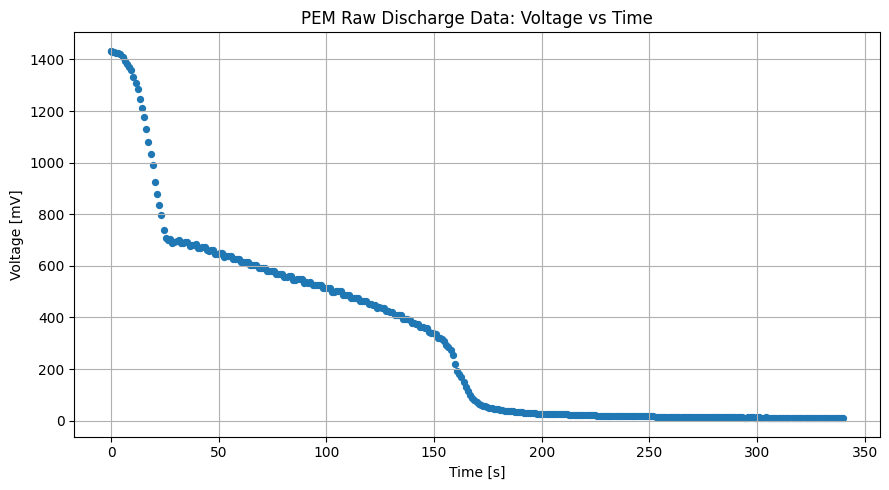

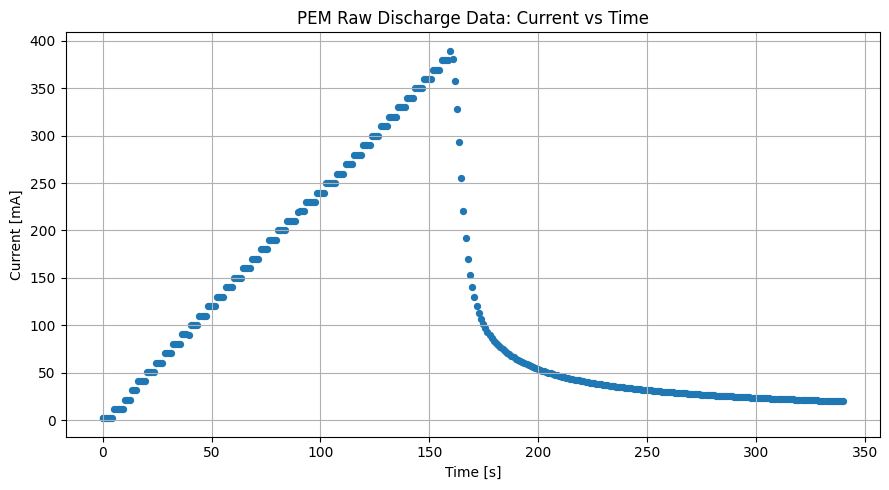

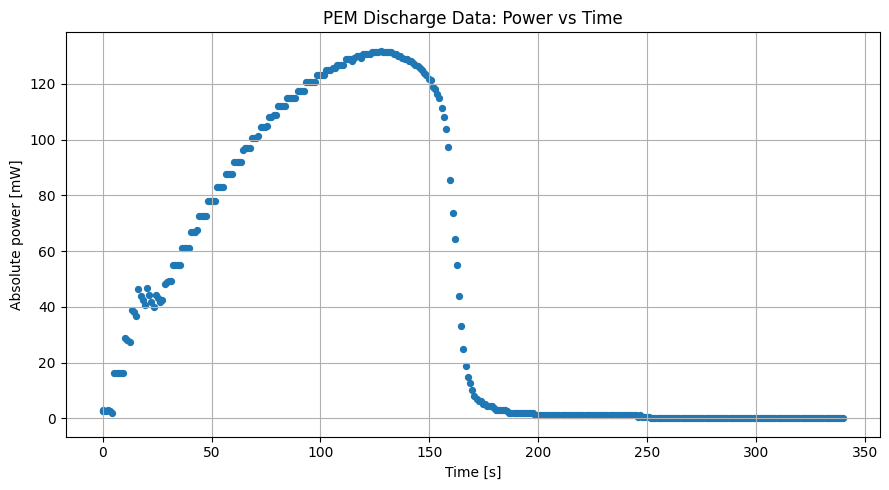

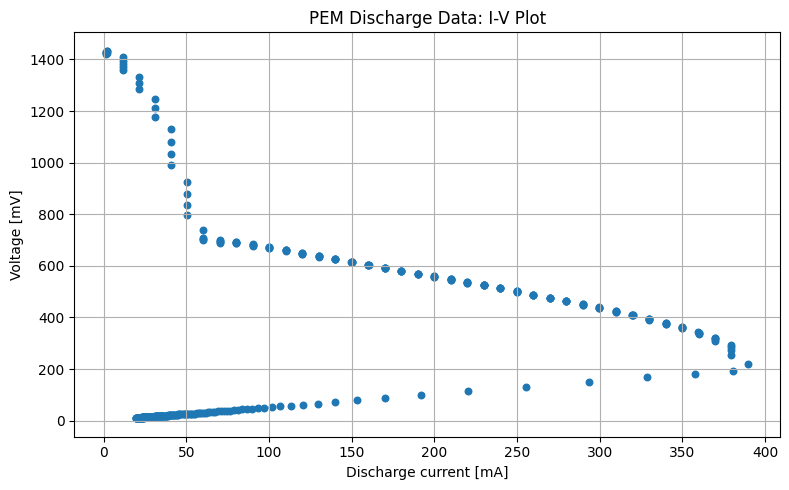

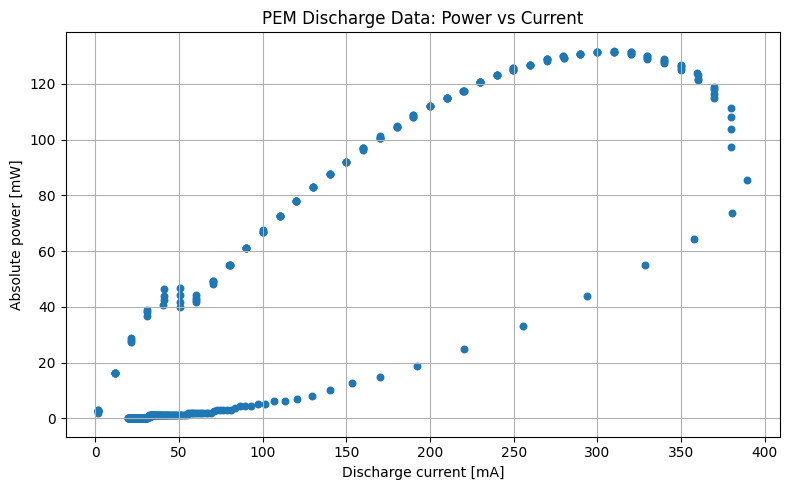


Matching point check:
                    pc_time  elapsed_s  V_mV  I_mA_discharge  P_mW_abs
171 2026-04-23 10:59:29.564     169.71  71.2           140.2      10.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# File
# --------------------------------------------------
csv_path = Path("PEM_ina226_Fast_Discharge_Steps.csv")

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_csv(csv_path)

df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["elapsed_s", "bus_V", "current_mA"]).copy()

# --------------------------------------------------
# Convert to desired units
# --------------------------------------------------
# In the discharge log, current is negative, so flip sign
# so discharge current becomes positive in mA.
df["I_mA_discharge"] = -df["current_mA"]
df["V_mV"] = df["bus_V"] * 1000.0
df["P_mW_abs"] = df["power_mW"].abs()

# Keep only real discharge points
df_dis = df[df["I_mA_discharge"] > 0].copy()

if df_dis.empty:
    raise ValueError("No valid discharge points found.")

print("Number of raw discharge points:", len(df_dis))
print(df_dis[["pc_time", "elapsed_s", "V_mV", "I_mA_discharge", "P_mW_abs"]].head(10))

# --------------------------------------------------
# Plot 1: Raw voltage vs time
# --------------------------------------------------
plt.figure(figsize=(9, 5))
plt.scatter(df_dis["elapsed_s"], df_dis["V_mV"], s=18)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.title("PEM Raw Discharge Data: Voltage vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2: Raw current vs time
# --------------------------------------------------
plt.figure(figsize=(9, 5))
plt.scatter(df_dis["elapsed_s"], df_dis["I_mA_discharge"], s=18)
plt.xlabel("Time [s]")
plt.ylabel("Current [mA]")
plt.title("PEM Raw Discharge Data: Current vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 3: Raw power vs time
# --------------------------------------------------
plt.figure(figsize=(9, 5))
plt.scatter(df_dis["elapsed_s"], df_dis["P_mW_abs"], s=18)
plt.xlabel("Time [s]")
plt.ylabel("Absolute power [mW]")
plt.title("PEM Discharge Data: Power vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 4: Raw I-V plot
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df_dis["I_mA_discharge"], df_dis["V_mV"], s=22)
plt.xlabel("Discharge current [mA]")
plt.ylabel("Voltage [mV]")
plt.title("PEM Discharge Data: I-V Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 5: Raw power vs current
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df_dis["I_mA_discharge"], df_dis["P_mW_abs"], s=22)
plt.xlabel("Discharge current [mA]")
plt.ylabel("Absolute power [mW]")
plt.title("PEM Discharge Data: Power vs Current")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Optional check for a specific point
# Example:
# 2026-04-23 10:59:29.564,169.710,0.0712,-140.2000,10.0000,-14.0249
# --------------------------------------------------
mask = (
    (df_dis["elapsed_s"].sub(169.710).abs() < 0.01) &
    (df_dis["V_mV"].sub(71.2).abs() < 1.0) &
    (df_dis["I_mA_discharge"].sub(140.2).abs() < 1.0)
)

print("\nMatching point check:")
print(df_dis.loc[mask, ["pc_time", "elapsed_s", "V_mV", "I_mA_discharge", "P_mW_abs"]])

#### OLD


Charge dataset
--------------
Samples:              965
Voltage range [V]:    0.5088 -> 1.8850
Current range [A]:    0.0092 -> 0.3066
Power range [W]:      0.0050 -> 0.5781

Discharge segments found:
  Segment 1: 298 samples, time 2026-04-23 10:09:06.546000 -> 2026-04-23 10:14:04.137000, I range 0.0106 to 0.1901 A
  Segment 2: 158 samples, time 2026-04-23 10:20:13.854000 -> 2026-04-23 10:22:51.160000, I range 0.2000 to 0.2898 A
  Segment 3: 106 samples, time 2026-04-23 10:26:16.511000 -> 2026-04-23 10:27:59.772000, I range 0.2998 to 0.3599 A


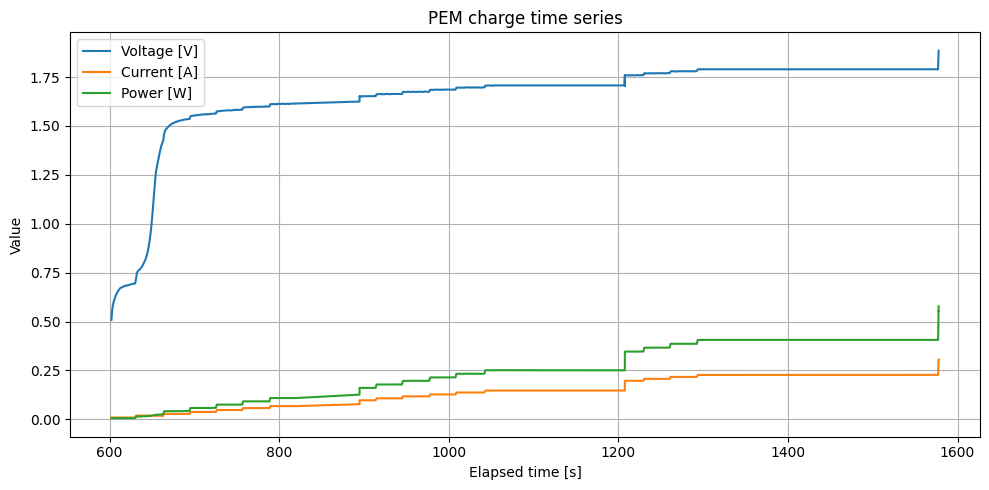

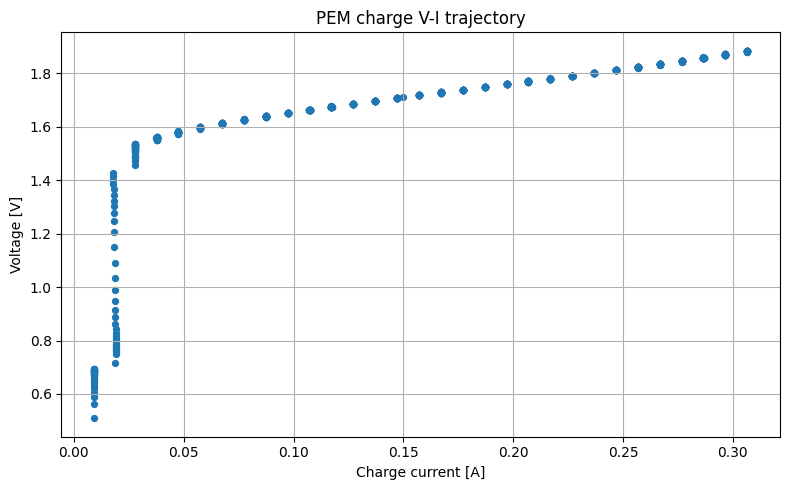

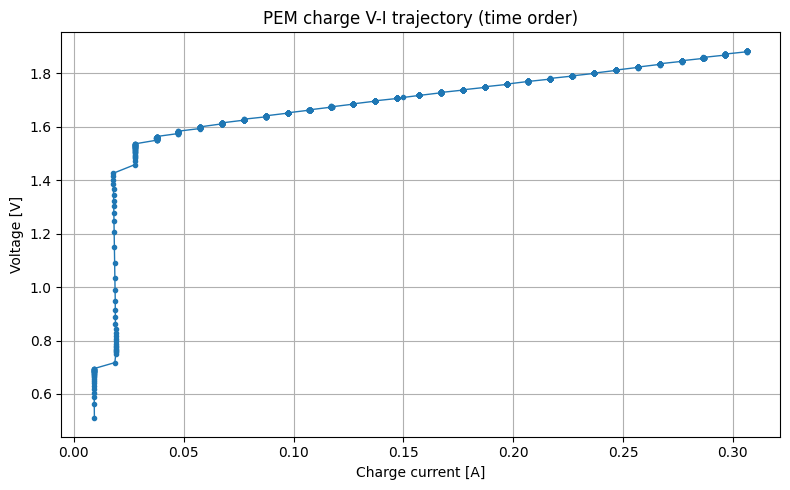

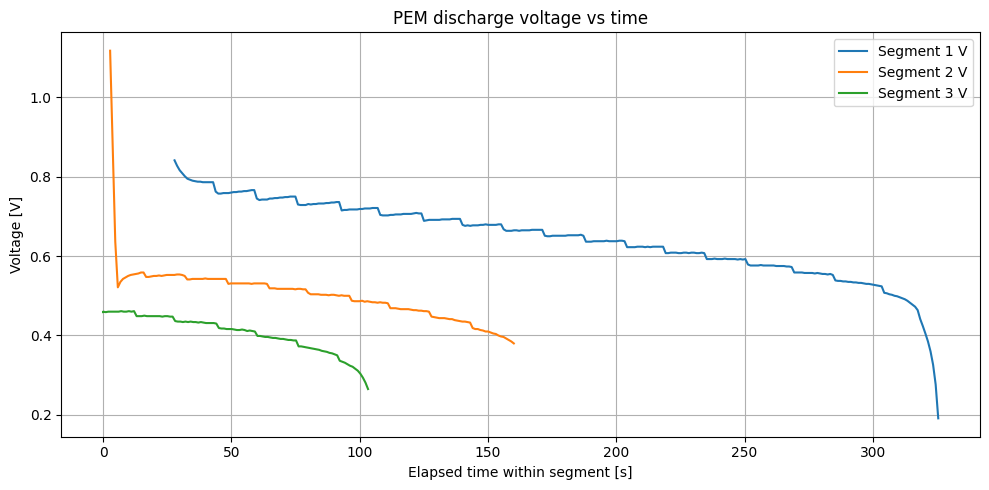

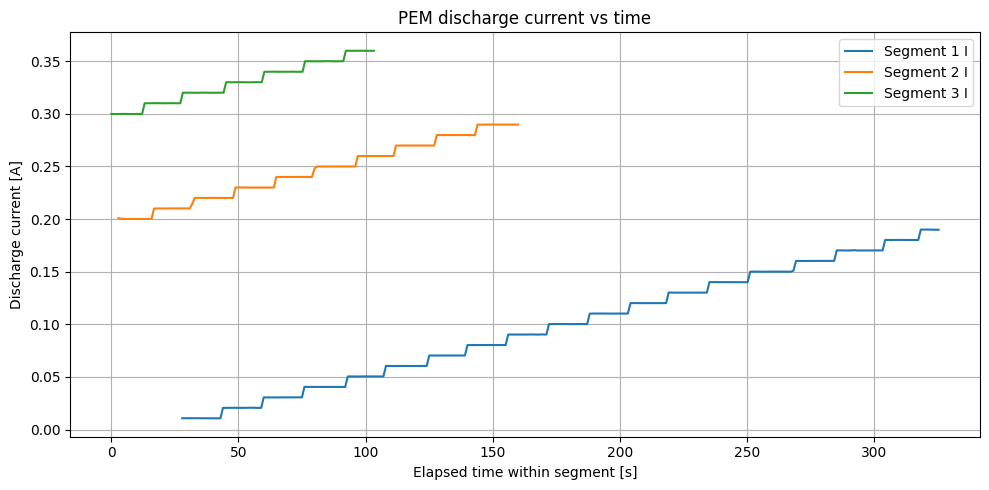

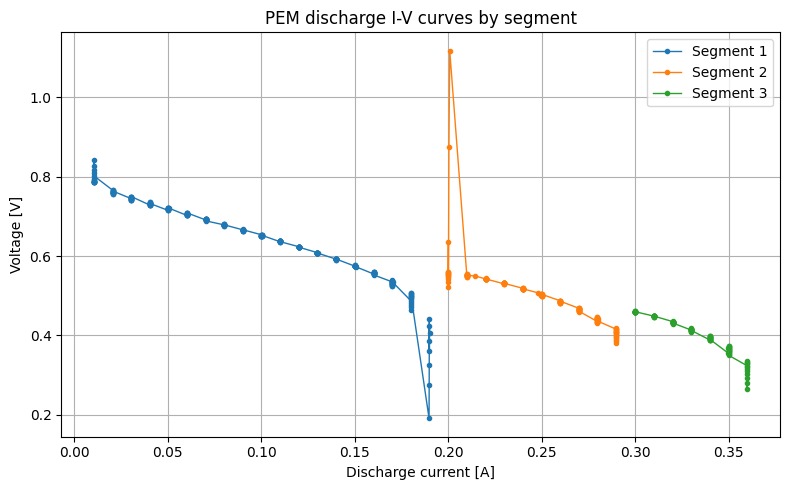

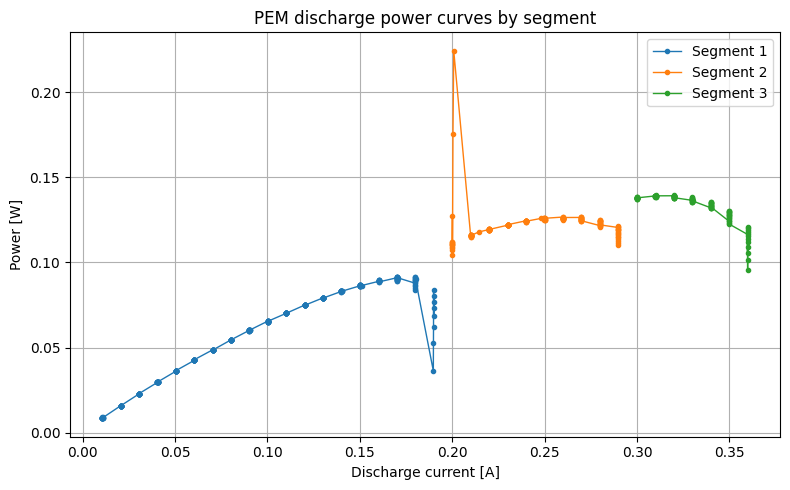

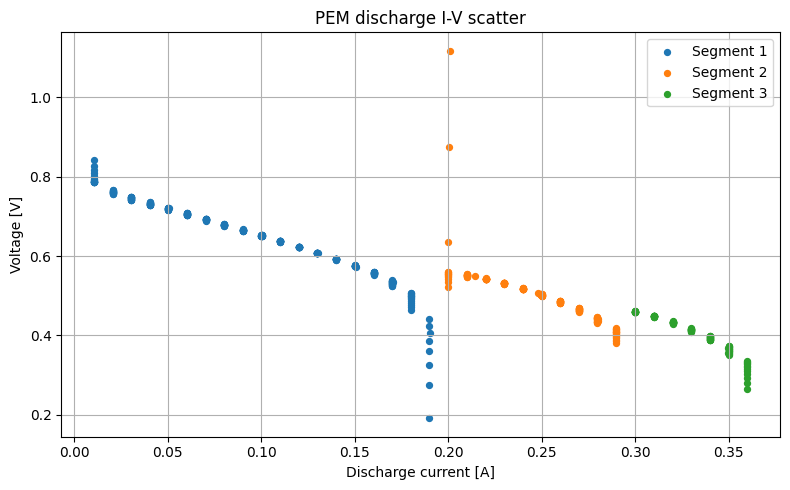


Discharge segment 1
----------------------
Samples: 298
Voltage range [V]: 0.1912 -> 0.8413
Current range [A]: 0.0106 -> 0.1901
Max power [W]:     0.0917
At max power:      V = 0.5387 V, I = 0.1703 A

Discharge segment 2
----------------------
Samples: 158
Voltage range [V]: 0.3800 -> 1.1175
Current range [A]: 0.2000 -> 0.2898
Max power [W]:     0.2244
At max power:      V = 1.1175 V, I = 0.2009 A

Discharge segment 3
----------------------
Samples: 106
Voltage range [V]: 0.2650 -> 0.4613
Current range [A]: 0.2998 -> 0.3599
Max power [W]:     0.1396
At max power:      V = 0.4363 V, I = 0.3201 A


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# File paths
# ============================================================
charge_file = Path("PEM_Charge_0_310mA.csv")
discharge_file = Path("PEM_Discharge_0_350mA.csv")

# Known interruption timestamps in discharge test
manual_reset_times = [
    "2026-04-23 10:14:05.137",
    "2026-04-23 10:22:52.137",
]

# ============================================================
# Helpers
# ============================================================
def load_pem_csv(path):
    df = pd.read_csv(path)
    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

    numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["pc_time", "elapsed_s", "bus_V", "current_mA"]).copy()

    df["V_V"] = df["bus_V"]
    df["I_A"] = df["current_mA"] / 1000.0
    df["P_W"] = df["power_mW"] / 1000.0

    return df


def find_discharge_segments(df, manual_reset_times=None):
    """
    Detect discharge segments when elapsed_s resets or a zero-row appears.
    """
    df = df.sort_values("pc_time").reset_index(drop=True).copy()

    reset_flags = pd.Series(False, index=df.index)

    # elapsed_s reset
    reset_flags |= df["elapsed_s"].diff().fillna(0) < -1

    # zero row / inserted marker
    reset_flags |= (
        (df["elapsed_s"] == 0)
        & (df["bus_V"].abs() < 1e-9)
        & (df["current_mA"].abs() < 1e-9)
    )

    # manual timestamps
    if manual_reset_times is not None:
        manual_reset_times = pd.to_datetime(manual_reset_times)
        for ts in manual_reset_times:
            matches = df.index[df["pc_time"] == ts]
            if len(matches) > 0:
                reset_flags.loc[matches[0]] = True

    df["segment_id"] = reset_flags.cumsum()

    # remove the artificial zero marker rows from actual analysis
    valid = ~(
        (df["elapsed_s"] == 0)
        & (df["bus_V"].abs() < 1e-9)
        & (df["current_mA"].abs() < 1e-9)
    )

    df = df[valid].copy()

    # reindex segment ids to 1,2,3,...
    unique_ids = sorted(df["segment_id"].unique())
    id_map = {old: i + 1 for i, old in enumerate(unique_ids)}
    df["segment_id"] = df["segment_id"].map(id_map)

    return df


def summarize_curve(df, label):
    print(f"\n{label}")
    print("-" * len(label))
    print(f"Samples:              {len(df)}")
    print(f"Voltage range [V]:    {df['V_V'].min():.4f} -> {df['V_V'].max():.4f}")
    print(f"Current range [A]:    {df['I_A'].min():.4f} -> {df['I_A'].max():.4f}")
    print(f"Power range [W]:      {df['P_W'].min():.4f} -> {df['P_W'].max():.4f}")


# ============================================================
# Load data
# ============================================================
charge_df = load_pem_csv(charge_file)
discharge_df = load_pem_csv(discharge_file)

# ============================================================
# Charge processing
# ============================================================
# Keep actual charging points only
charge = charge_df[charge_df["I_A"] > 0].copy()

# Optional: remove tiny idle current points
charge = charge[charge["I_A"] > 0.002].copy()

if charge.empty:
    raise ValueError("No positive-current charging data found.")

summarize_curve(charge, "Charge dataset")

# ============================================================
# Discharge processing
# ============================================================
# Your discharge current is negative in the log, so use magnitude
discharge_df["I_discharge_A"] = -discharge_df["I_A"]

# Keep actual discharge points only
discharge = discharge_df[discharge_df["I_discharge_A"] > 0.002].copy()

if discharge.empty:
    raise ValueError("No valid discharge data found.")

discharge = find_discharge_segments(discharge, manual_reset_times=manual_reset_times)

print("\nDischarge segments found:")
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id]
    print(
        f"  Segment {seg_id}: "
        f"{len(seg)} samples, "
        f"time {seg['pc_time'].min()} -> {seg['pc_time'].max()}, "
        f"I range {seg['I_discharge_A'].min():.4f} to {seg['I_discharge_A'].max():.4f} A"
    )

# ============================================================
# Plot 1: Charge time series
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(charge["elapsed_s"], charge["V_V"], label="Voltage [V]")
plt.plot(charge["elapsed_s"], charge["I_A"], label="Current [A]")
plt.plot(charge["elapsed_s"], charge["P_W"], label="Power [W]")
plt.xlabel("Elapsed time [s]")
plt.ylabel("Value")
plt.title("PEM charge time series")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: Charge V-I trajectory
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(charge["I_A"], charge["V_V"], s=18)
plt.xlabel("Charge current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM charge V-I trajectory")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Charge V-I trajectory with time order
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(charge["I_A"], charge["V_V"], marker="o", markersize=3, linewidth=1)
plt.xlabel("Charge current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM charge V-I trajectory (time order)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: Discharge time series by segment
# ============================================================
plt.figure(figsize=(10, 5))
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id]
    plt.plot(seg["elapsed_s"], seg["V_V"], label=f"Segment {seg_id} V")
plt.xlabel("Elapsed time within segment [s]")
plt.ylabel("Voltage [V]")
plt.title("PEM discharge voltage vs time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id]
    plt.plot(seg["elapsed_s"], seg["I_discharge_A"], label=f"Segment {seg_id} I")
plt.xlabel("Elapsed time within segment [s]")
plt.ylabel("Discharge current [A]")
plt.title("PEM discharge current vs time")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5: Discharge I-V curve, segmented
# ============================================================
plt.figure(figsize=(8, 5))
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id].sort_values("I_discharge_A")
    plt.plot(seg["I_discharge_A"], seg["V_V"], marker="o", markersize=3, linewidth=1, label=f"Segment {seg_id}")
plt.xlabel("Discharge current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM discharge I-V curves by segment")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 6: Discharge power curves by segment
# ============================================================
plt.figure(figsize=(8, 5))
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id].copy()
    seg["P_calc_W"] = seg["V_V"] * seg["I_discharge_A"]
    seg = seg.sort_values("I_discharge_A")
    plt.plot(seg["I_discharge_A"], seg["P_calc_W"], marker="o", markersize=3, linewidth=1, label=f"Segment {seg_id}")
plt.xlabel("Discharge current [A]")
plt.ylabel("Power [W]")
plt.title("PEM discharge power curves by segment")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 7: All discharge points as scatter
# ============================================================
plt.figure(figsize=(8, 5))
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id]
    plt.scatter(seg["I_discharge_A"], seg["V_V"], s=18, label=f"Segment {seg_id}")
plt.xlabel("Discharge current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM discharge I-V scatter")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Extra summary
# ============================================================
for seg_id in sorted(discharge["segment_id"].unique()):
    seg = discharge[discharge["segment_id"] == seg_id].copy()
    seg["P_calc_W"] = seg["V_V"] * seg["I_discharge_A"]
    pmax_idx = seg["P_calc_W"].idxmax()

    print(f"\nDischarge segment {seg_id}")
    print("----------------------")
    print(f"Samples: {len(seg)}")
    print(f"Voltage range [V]: {seg['V_V'].min():.4f} -> {seg['V_V'].max():.4f}")
    print(f"Current range [A]: {seg['I_discharge_A'].min():.4f} -> {seg['I_discharge_A'].max():.4f}")
    print(f"Max power [W]:     {seg.loc[pmax_idx, 'P_calc_W']:.4f}")
    print(f"At max power:      V = {seg.loc[pmax_idx, 'V_V']:.4f} V, I = {seg.loc[pmax_idx, 'I_discharge_A']:.4f} A")

PEM charging analysis
---------------------
Total samples:              1656
Charging samples used:      1226
Charging time span:         3.81 s to 1231.25 s
Initial charging voltage:   1.0662 V
Final charging voltage:     1.7025 V
Mean charging current:      0.1235 A
Max charging current:       0.1359 A
Max charging power:         0.2112 W


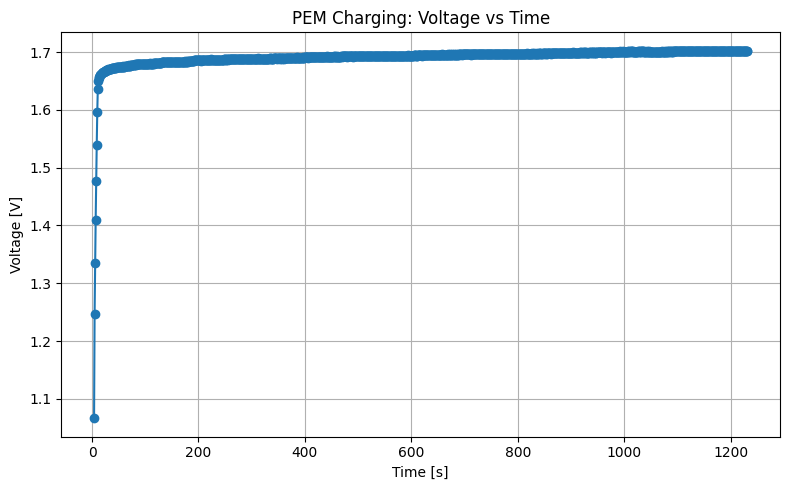

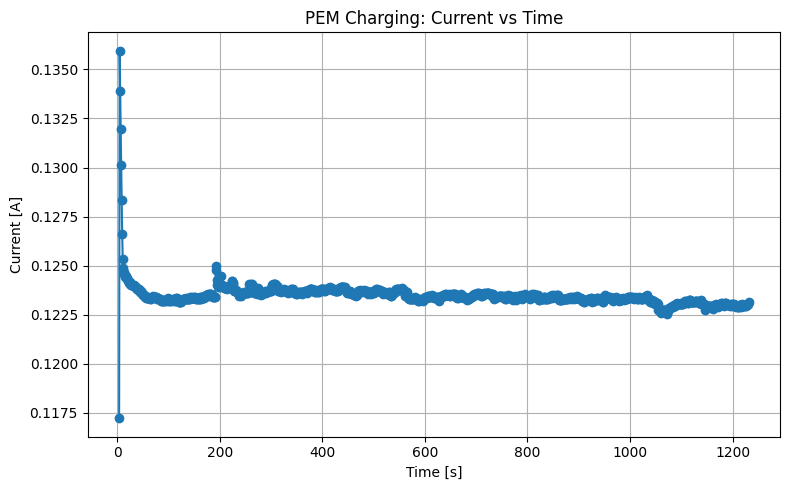

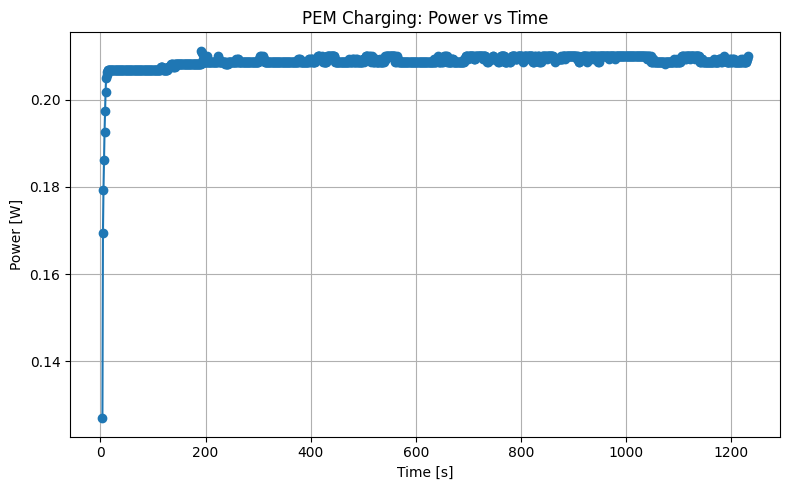

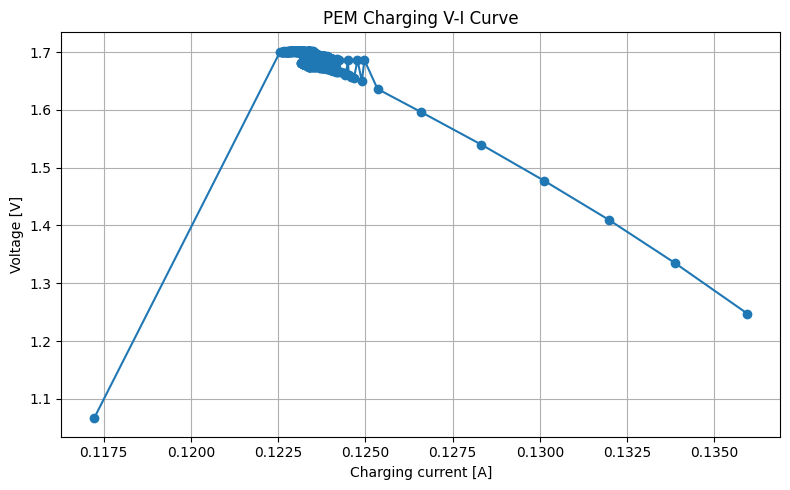

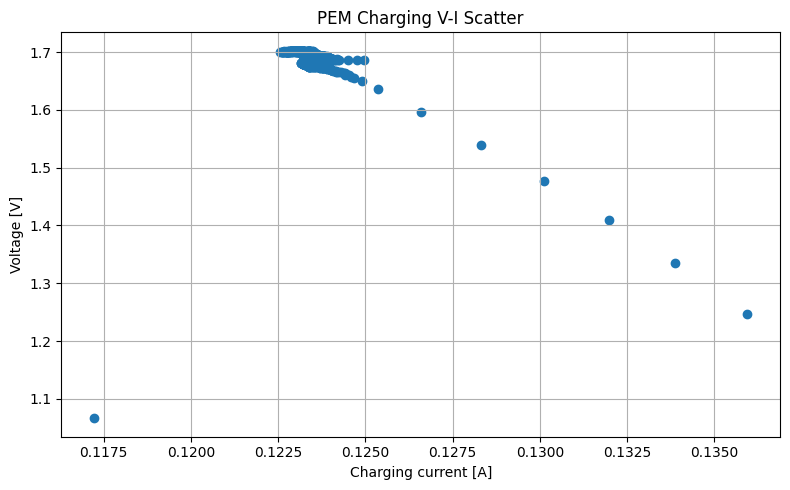

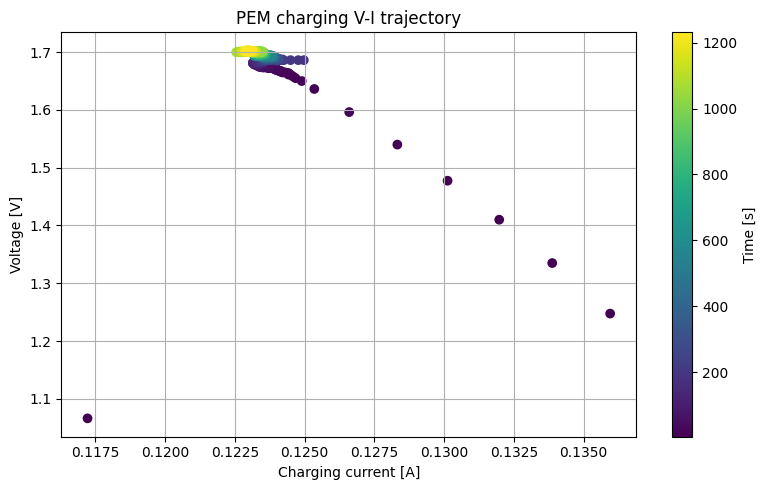

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Settings
# --------------------------------------------------
csv_path = Path("PEM_ina226_log_20260422_161423.csv")   # Change to your actual filename

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_csv(csv_path, sep=",")

# Parse columns
df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

numeric_cols = ["elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["elapsed_s", "bus_V", "current_mA"]).copy()

# --------------------------------------------------
# Create useful columns
# --------------------------------------------------
df["V_V"] = df["bus_V"]
df["I_A"] = df["current_mA"] / 1000.0
df["P_W"] = df["power_mW"] / 1000.0

# Positive current = charging
charge = df[df["I_A"] > 0.001].copy()

# Sort by current for a cleaner V-I curve
charge_iv = charge.sort_values("I_A").copy()

if charge.empty:
    raise ValueError("No positive charging-current samples were found in the CSV.")

# --------------------------------------------------
# Print summary
# --------------------------------------------------
print("PEM charging analysis")
print("---------------------")
print(f"Total samples:              {len(df)}")
print(f"Charging samples used:      {len(charge)}")
print(f"Charging time span:         {charge['elapsed_s'].min():.2f} s to {charge['elapsed_s'].max():.2f} s")
print(f"Initial charging voltage:   {charge.iloc[0]['V_V']:.4f} V")
print(f"Final charging voltage:     {charge.iloc[-1]['V_V']:.4f} V")
print(f"Mean charging current:      {charge['I_A'].mean():.4f} A")
print(f"Max charging current:       {charge['I_A'].max():.4f} A")
print(f"Max charging power:         {charge['P_W'].max():.4f} W")

# --------------------------------------------------
# Plot 1: Voltage vs time
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(charge["elapsed_s"], charge["V_V"], marker="o", linestyle="-")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.title("PEM Charging: Voltage vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2: Current vs time
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(charge["elapsed_s"], charge["I_A"], marker="o", linestyle="-")
plt.xlabel("Time [s]")
plt.ylabel("Current [A]")
plt.title("PEM Charging: Current vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 3: Power vs time
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(charge["elapsed_s"], charge["P_W"], marker="o", linestyle="-")
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")
plt.title("PEM Charging: Power vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 4: Charging V-I curve
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(charge_iv["I_A"], charge_iv["V_V"], marker="o", linestyle="-")
plt.xlabel("Charging current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM Charging V-I Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Optional: Scatter version of charging V-I curve
# (useful if points overlap a lot)
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(charge["I_A"], charge["V_V"])
plt.xlabel("Charging current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM Charging V-I Scatter")
plt.grid(True)
plt.tight_layout()
plt.show()

# time-ordered scatter
plt.figure(figsize=(8,5))
plt.scatter(charge["I_A"], charge["V_V"], c=charge["elapsed_s"])
plt.xlabel("Charging current [A]")
plt.ylabel("Voltage [V]")
plt.title("PEM charging V-I trajectory")
plt.grid(True)
plt.colorbar(label="Time [s]")
plt.tight_layout()
plt.show()